# About

This notebook contains example code for modeling Mie scattering (scattering on a sphere) not only for a plane wave, but also for a spherical wave.
The main purpose of this file is to verify that the code works correctly, in addition to the existing tests.

First, the expansion of the incident wave is demonstrated.
The convergence of this expansion with respect to the number of harmonics is analyzed.

Second, the Lorentz–Mie coefficients for a sphere are tested.
The test is performed by comparing the extinction cross section calculated with COMSOL to that obtained from these coefficients.


# Incident Wave

Inside the sphere ($r < a$), the incident field can be expanded as follows:
$$
p_\text{b} = \sum_{n=0}^{N} p_n j_n^{(1)}(kr) P_n(\cos\theta)
$$

For a **plane wave** (PW), $p_\text{b} = e^{ikz}$, it is known that:
$$
p_n = i^n (2n+1)
$$

For a **spherical wave** (SW)
$$
p_\text{b} = R \frac{e^{ikz}}{z+R}
$$
the expansion coefficients take the form:
$$
p_n = i^n (2n+1)\left[\frac{kR}{e^{ikR}}(i)^{n+1} h_n^{(1)}(kR)\right]
$$

Let’s check whether the provided $p_n$ coefficients are correct.
To do this, we will examine the convergence of the reconstructed field with respect to the truncation order $N$.

In [1]:
import scipy.special as sp
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import Normalize

from mie_utils import (
    p_n_PW,
    p_n_SW,
    plane_p_b_generator,
    plane_p_b_PW,
    plane_p_b_SW,
    a_n_sphere,
)

In [2]:
a = 1  # Sphere radius
c_host = 1  # Speed of sound in the host medium
rho_host = 1  # Density of the host medium
c_sphere = 0.3  # Speed of sound inside the sphere
rho_sphere = 1  # Density of the sphere

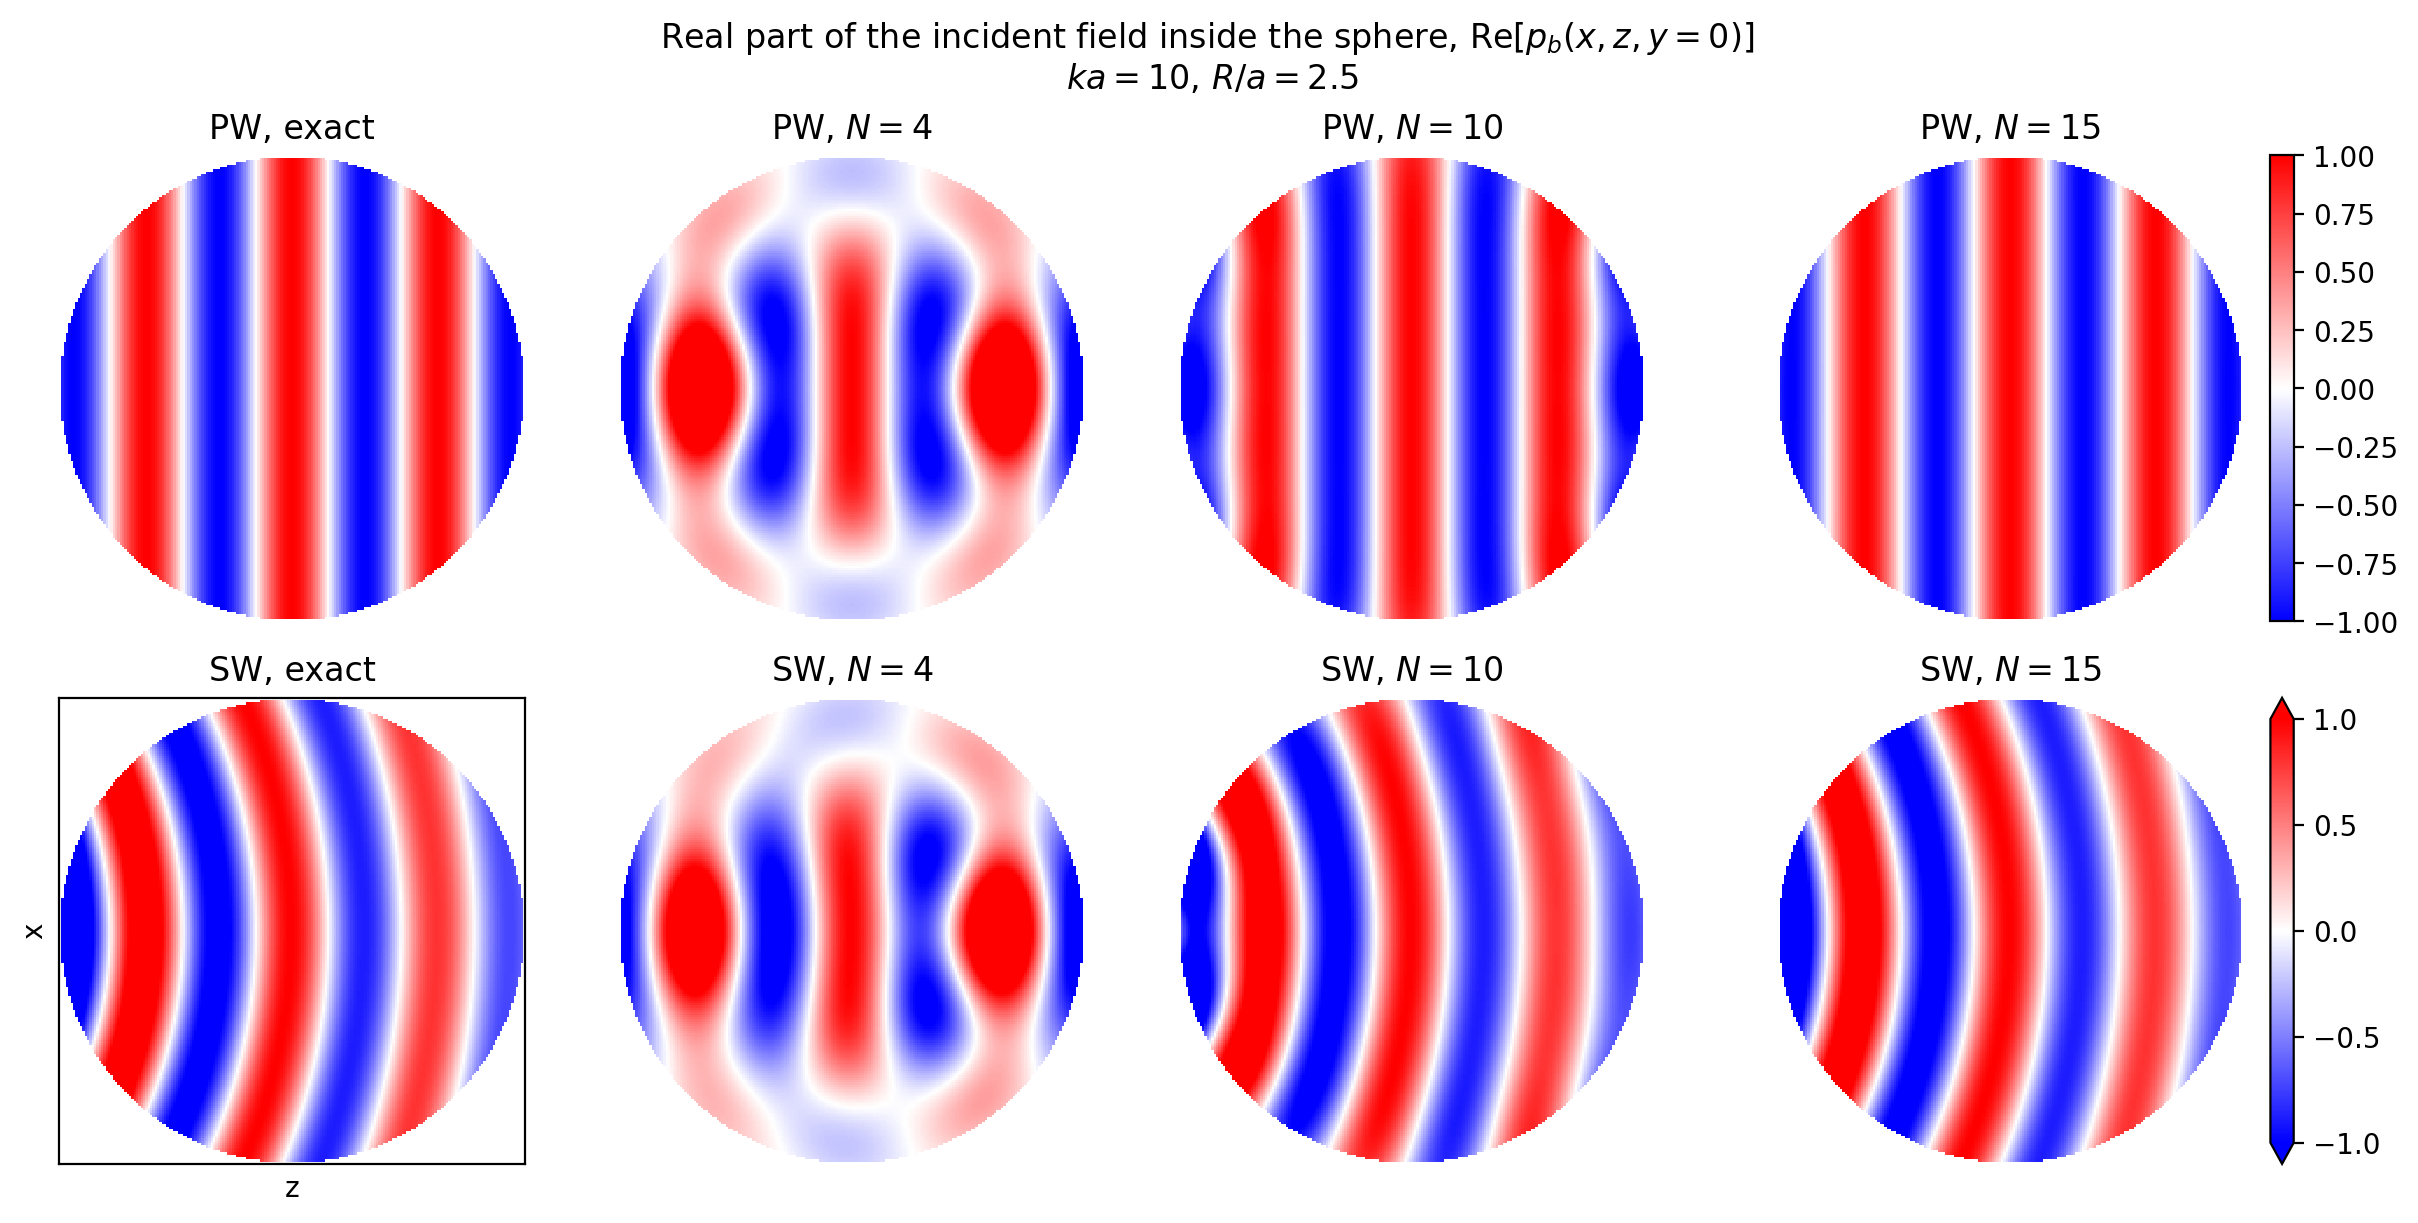

In [3]:
k = 10  # Wave number
R = 2.5  # Distance of the point source from the sphere center


# Grid of points where the field will be evaluated
N_points = 200
Z, X = np.meshgrid(np.linspace(-a, a, N_points), np.linspace(-a, a, N_points))

N_list = [None, 4, 10, 15]

plt.subplots(2, len(N_list), figsize=(12, 6), layout="constrained", dpi=200)

for i, N in enumerate(N_list):

    # ====== First row ======
    plt.subplot(2, len(N_list), i + 1)

    if N is None:
        p_b = plane_p_b_PW(Z, X, a, k)
    else:
        p_n = p_n_PW(N)
        p_b = sum(plane_p_b_generator(Z, X, a, k, p_n))

    plt.pcolormesh(Z, X, np.real(p_b), shading="auto", vmax=1, vmin=-1, cmap="bwr")

    # ====== Style ======
    plt.gca().set_aspect("equal")
    plt.xticks([])
    plt.yticks([])
    plt.gca().set_axis_off()
    if N is None:
        plt.title("PW, exact")
    else:
        plt.title(f"PW, $N={N}$")
    if i == len(N_list) - 1:
        plt.colorbar()

    # ====== Second row ======
    plt.subplot(
        2,
        len(N_list),
        len(N_list) + i + 1,
    )

    if N is None:
        p_b = plane_p_b_SW(Z, X, a, k, R)
    else:
        p_n = p_n_SW(N, k, R)
        p_b = sum(plane_p_b_generator(Z, X, a, k, p_n))

    plt.pcolormesh(Z, X, np.real(p_b), shading="auto", vmax=1, vmin=-1, cmap="bwr")

    # ====== Style ======
    plt.gca().set_aspect("equal")
    plt.xticks([])
    plt.yticks([])
    if i == 0:
        plt.xlabel("z")
        plt.ylabel("x")
    else:
        plt.gca().set_axis_off()
    if i == len(N_list) - 1:
        plt.colorbar(extend="both")
    if N is None:
        plt.title("SW, exact")
    else:
        plt.title(f"SW, $N={N}$")

plt.suptitle(
    f"Real part of the incident field inside the sphere, $\\text{{Re}}[p_b(x, z, y=0)]$\n $ka={k*a}$, $R/a = {R/a}$"
)

plt.show()

This figure gives hope.
To demonstrate the convergence with respect to $N$, we now calculate the mean absolute error of the background pressure field on the $xz$-plane inside the spherical region.

In [4]:
def errors_PW():
    """Generate error data for the plane-wave expansion test.
    Computes the mean absolute error of the reconstructed background plane wave field
    inside the sphere for different wavenumbers (k) and truncation orders (N).
    """

    k_list = [1, 5, 10, 15, 20]  # Wavenumbers to evaluate
    N_list = np.logspace(0.1, 3, 30, dtype=int)  # N to evaluate

    # Evaluate the field on an (N_points x N_points) grid in the xz-plane
    N_points = 50
    Z, X = np.meshgrid(np.linspace(-a, a, N_points), np.linspace(-a, a, N_points))

    for k in k_list:
        p_b_exact = plane_p_b_PW(Z, X, a, k)  # Exact field in the xz-plane

        # Compute all partial sums of the series expansion
        p_n = p_n_PW(max(N_list))  # Expansion coefficients for PW
        p_b_N = np.cumsum(list(plane_p_b_generator(Z, X, a, k, p_n)), axis=0)

        N_calculated_list = list(np.arange(max(N_list) + 1))

        for N in N_list:
            i = N_calculated_list.index(N)  # Index corresponding to truncation N
            error = np.nanmean(np.abs(p_b_N[i] - p_b_exact))

            yield {"ka": k * a, "N": N, "error": error}


df_errors_PW = pd.DataFrame(errors_PW())

In [5]:
def errors_SW():
    """Generate error data for the plane-wave expansion test.
    Computes the mean absolute error of the reconstructed background spherical wave field
    inside the sphere for different wavenumbers (k), positions of point source (R) and truncation orders (N).
    """

    R_list = [1.5, 2, 10]  # R to evaluate
    k_list = [1, 10, 20]  # Wavenumbers to evaluate
    N_list = np.logspace(0.1, 3, 30, dtype=int)  # N to evaluate

    # Evaluate the field on an (N_points x N_points) grid in the xz-plane
    N_points = 50
    Z, X = np.meshgrid(np.linspace(-a, a, N_points), np.linspace(-a, a, N_points))

    for R in R_list:
        for k in k_list:
            p_b_exact = plane_p_b_SW(Z, X, a, k, R)  # Exact field in the xz-plane

            # Compute all partial sums of the series expansion
            p_n = p_n_SW(max(N_list), k, R)  # Expansion coefficients for SW
            p_b_N = np.cumsum(list(plane_p_b_generator(Z, X, a, k, p_n)), axis=0)

            N_calculated_list = list(np.arange(max(N_list) + 1))

            for N in N_list:
                i = N_calculated_list.index(N)  # Index corresponding to truncation N
                error = np.nanmean(np.abs(p_b_N[i] - p_b_exact))

                yield {"ka": k * a, "R/a": R / a, "N": N, "error": error}


df_errors_SW = pd.DataFrame(errors_SW())

/Users/vigos/Documents/GitHub/paper-optical-theorem/src/mie_utils/fields.py:35: RuntimeWarning: invalid value encountered in multiply
  h_n = sp.spherical_jn(n_array, kR) + 1j * sp.spherical_yn(n_array, kR)
/Users/vigos/Documents/GitHub/paper-optical-theorem/src/mie_utils/fields.py:38: RuntimeWarning: overflow encountered in multiply
  p_n = (1j) ** n_array * (2 * n_array + 1) * coef
/Users/vigos/Documents/GitHub/paper-optical-theorem/src/mie_utils/fields.py:71: RuntimeWarning: invalid value encountered in multiply
  term = p_n[n] * sp.spherical_jn(n, k * rho) * P[n]
/var/folders/gb/c4dxrb656yvf36d5mf8p1ggw0000gn/T/ipykernel_41868/3578973877.py:27: RuntimeWarning: Mean of empty slice
  error = np.nanmean(np.abs(p_b_N[i] - p_b_exact))


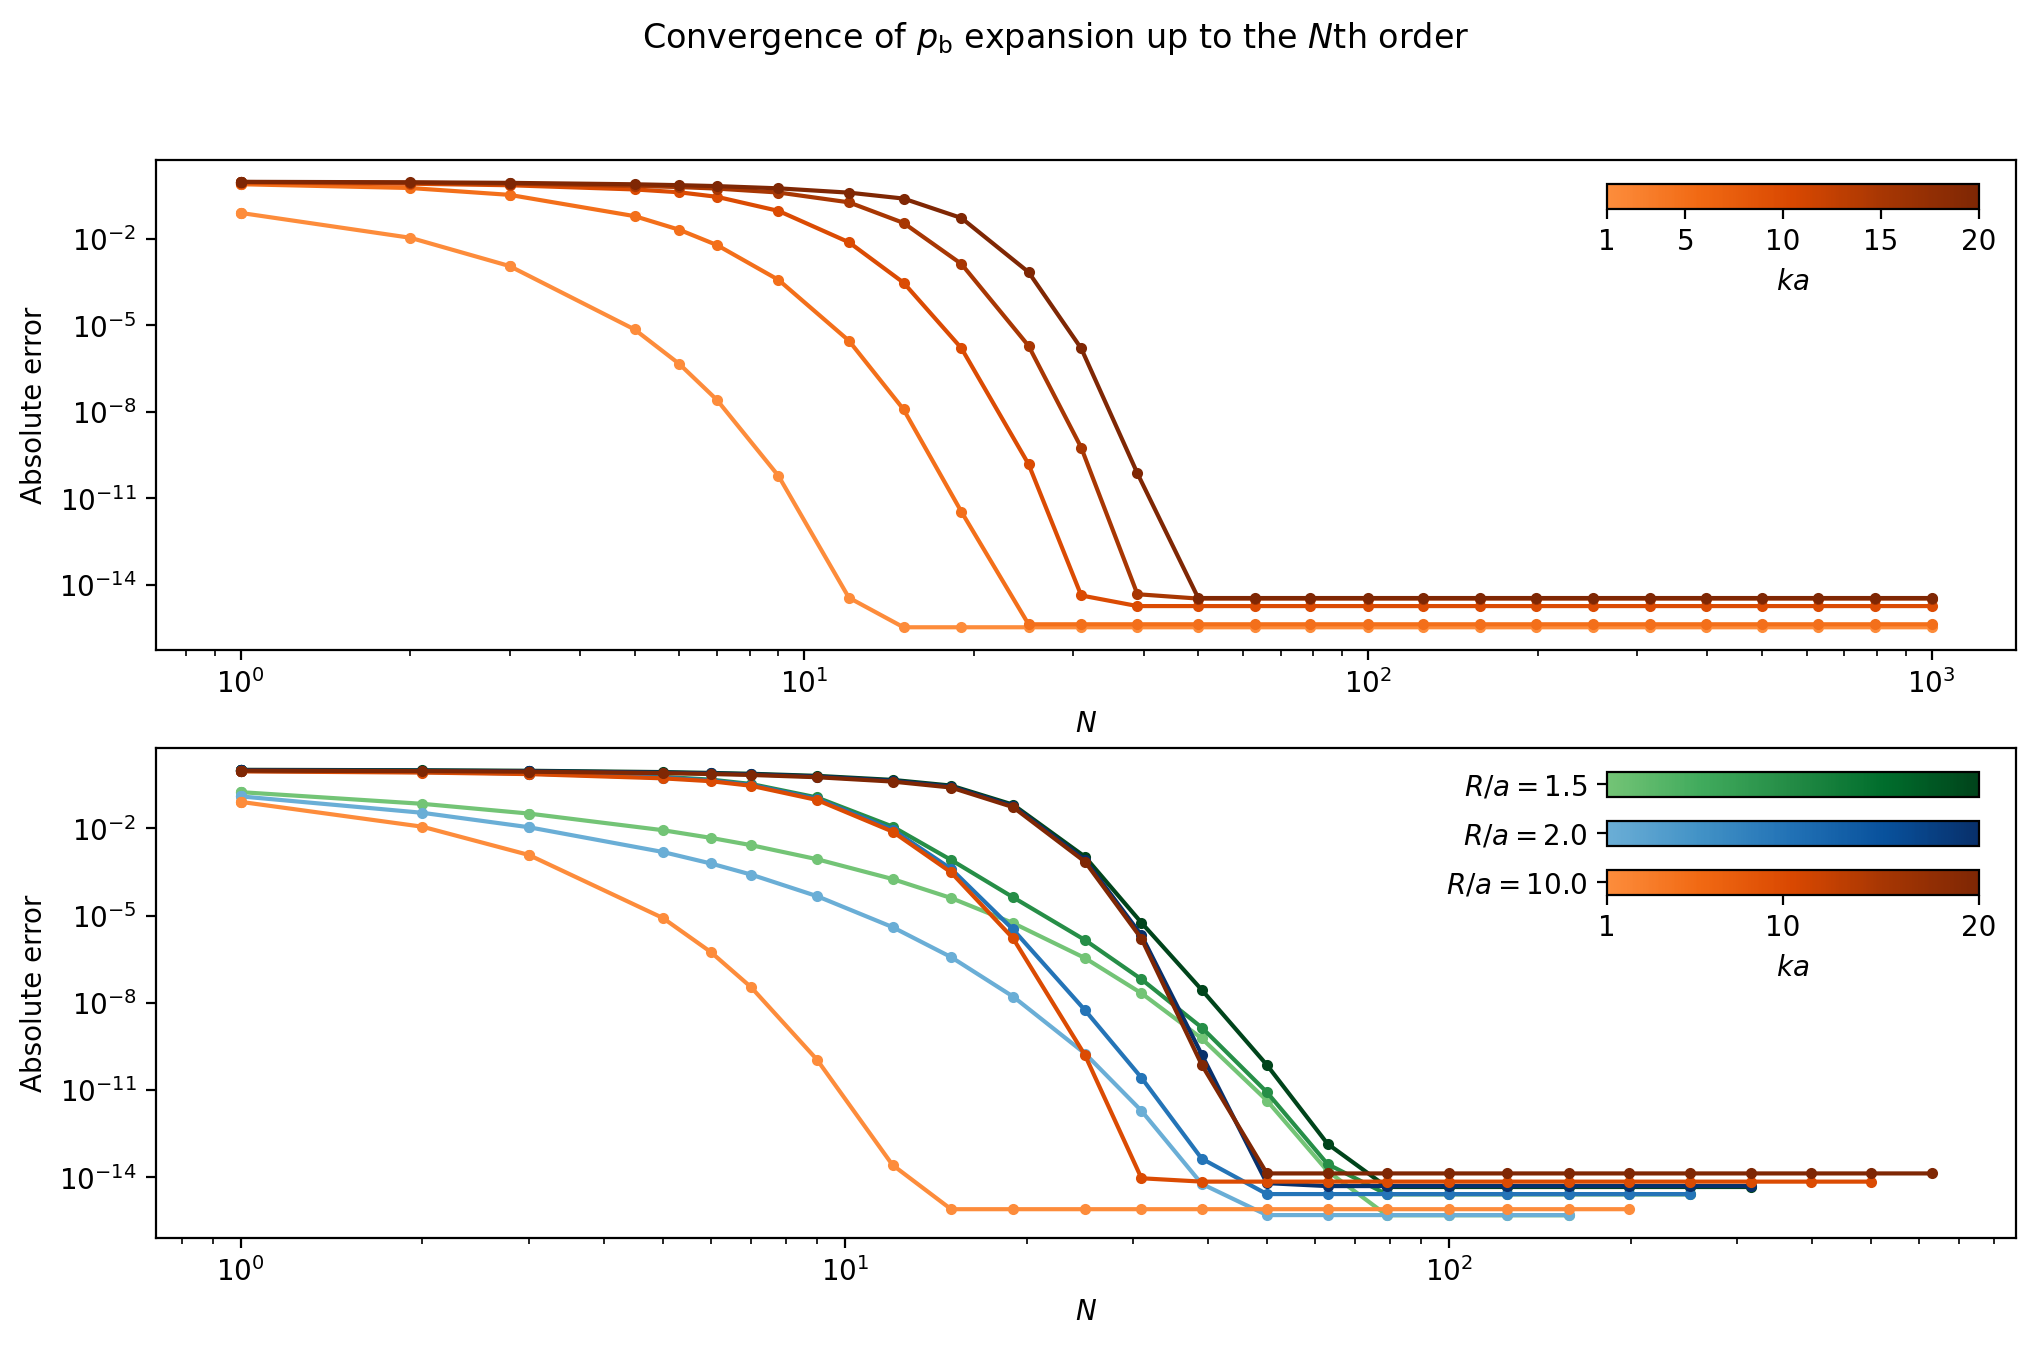

In [6]:
plt.figure(figsize=(12, 7), dpi=200)
plt.suptitle("Convergence of $p_\\text{b}$ expansion up to the $N$th order")


# ====== Plane Wave (PW) ======
plt.subplot(2, 1, 1)
ka_list = df_errors_PW["ka"].unique()
norm = Normalize(min(ka_list), max(ka_list))
cmap = LinearSegmentedColormap.from_list(
    "mycmap", plt.get_cmap("Oranges")(np.linspace(0.5, 1.0, 100))
)

# Plot mean absolute error vs N for each ka value
for ka in ka_list:
    sel = df_errors_PW[df_errors_PW["ka"] == ka]
    plt.plot(
        sel["N"],
        sel["error"],
        "-o",
        markersize=3,
        label=f"ka={ka}",
        color=cmap(norm(ka)),
    )

# ====== Style ======
# Add colorbar
new_axes = plt.gca().inset_axes((0.78, 0.90, 0.2, 0.05), transform=plt.gca().transAxes)
sm = ScalarMappable(norm=norm, cmap=cmap)
plt.colorbar(sm, new_axes, orientation="horizontal", ticks=ka_list, label="$ka$")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("$N$")
plt.ylabel("Absolute error")


# ====== Spherical Wave (SW) ======
plt.subplot(2, 1, 2)
R_a_list = df_errors_SW["R/a"].unique()
ka_list = df_errors_SW["ka"].unique()
norm = Normalize(min(ka_list), max(ka_list))
cmaps = (
    LinearSegmentedColormap.from_list(
        "mycmap", plt.get_cmap("Greens")(np.linspace(0.5, 1.0, 100))
    ),
    LinearSegmentedColormap.from_list(
        "mycmap", plt.get_cmap("Blues")(np.linspace(0.5, 1.0, 100))
    ),
    LinearSegmentedColormap.from_list(
        "mycmap", plt.get_cmap("Oranges")(np.linspace(0.5, 1.0, 100))
    ),
)

# Plot curves for each R/a and ka
for i, (R_a, cmap) in enumerate(zip(R_a_list, cmaps)):

    for ka in ka_list:
        sel = df_errors_SW[(df_errors_SW["ka"] == ka) & (df_errors_SW["R/a"] == R_a)]
        plt.plot(
            sel["N"],
            sel["error"],
            "-o",
            markersize=3,
            label=f"R/a={R_a}, ka={ka}",
            color=cmap(norm(ka)),
        )

    # Add colorbar
    new_axes = plt.gca().inset_axes(
        (0.78, 0.90 - 0.1 * i, 0.2, 0.05), transform=plt.gca().transAxes
    )
    sm = ScalarMappable(norm=norm, cmap=cmap)
    if i != len(R_a_list) - 1:
        plt.colorbar(sm, new_axes, orientation="horizontal")
        new_axes.set_xticks([])
    else:
        plt.colorbar(
            sm, new_axes, orientation="horizontal", ticks=ka_list, label="$ka$"
        )
    new_axes.set_yticks([0.5], labels=[f"$R/a={R_a}$"])


# ====== Style ======
plt.xscale("log")
plt.yscale("log")
plt.xlabel("$N$")
plt.ylabel("Absolute error")
plt.show()

OK, we have now verified that our expansions of the incident fields, specifically, the $p_n$ coefficients, are correct.

# Scatterred Field

The scattered field can also be expanded.
We consider only the scattered field outside the sphere ($r > a$), where the expansion is valid:
$$
p_s = \sum_{n=0}^{N} p_n a_n h_n^{(1)}(kr) P_n(\cos\theta)
$$

The coefficients $a_n$ are known as Mie coefficients (https://doi.org/10.1016/j.jsv.2020.115373)
$$
a_n = \frac{\alpha j_n'(ka)j_n(k'a) - j_n(ka)j_n'(k'a)}{h_n^{(1)}(ka)j_n'(k'a) - \alpha h^{(1)\prime}_n(ka)j_n(k'a)}
$$
Here, $\alpha = \frac{\rho' c'}{\rho c }$, $k' = \frac{\omega}{c'} = k\frac{c}{c'}$, $c'$ and $\rho'$ are the speed of sound and density of the sphere material, $c$ and $\rho$ are the speed of sound and density of the host medium.

For a plane wave, the extinction cross section is given by:
$$
\sigma_\text{ext}^\text{exact} = - \frac{4\pi}{k^2} \sum_n^N (2n+1) \text{Re}(a_n)
$$

We will now check whether the expression for $\sigma_\text{ext}^\text{exact}$ converges with respect to the truncation order $N$.

Load COMSOL model results for comparison
The results were generated using a COMSOL model that can be built and executed via Python.
See example scripts in the `comsol` folder.

In [7]:
df_comsol = pd.read_csv("data/sphere_comsol/sigma.csv")

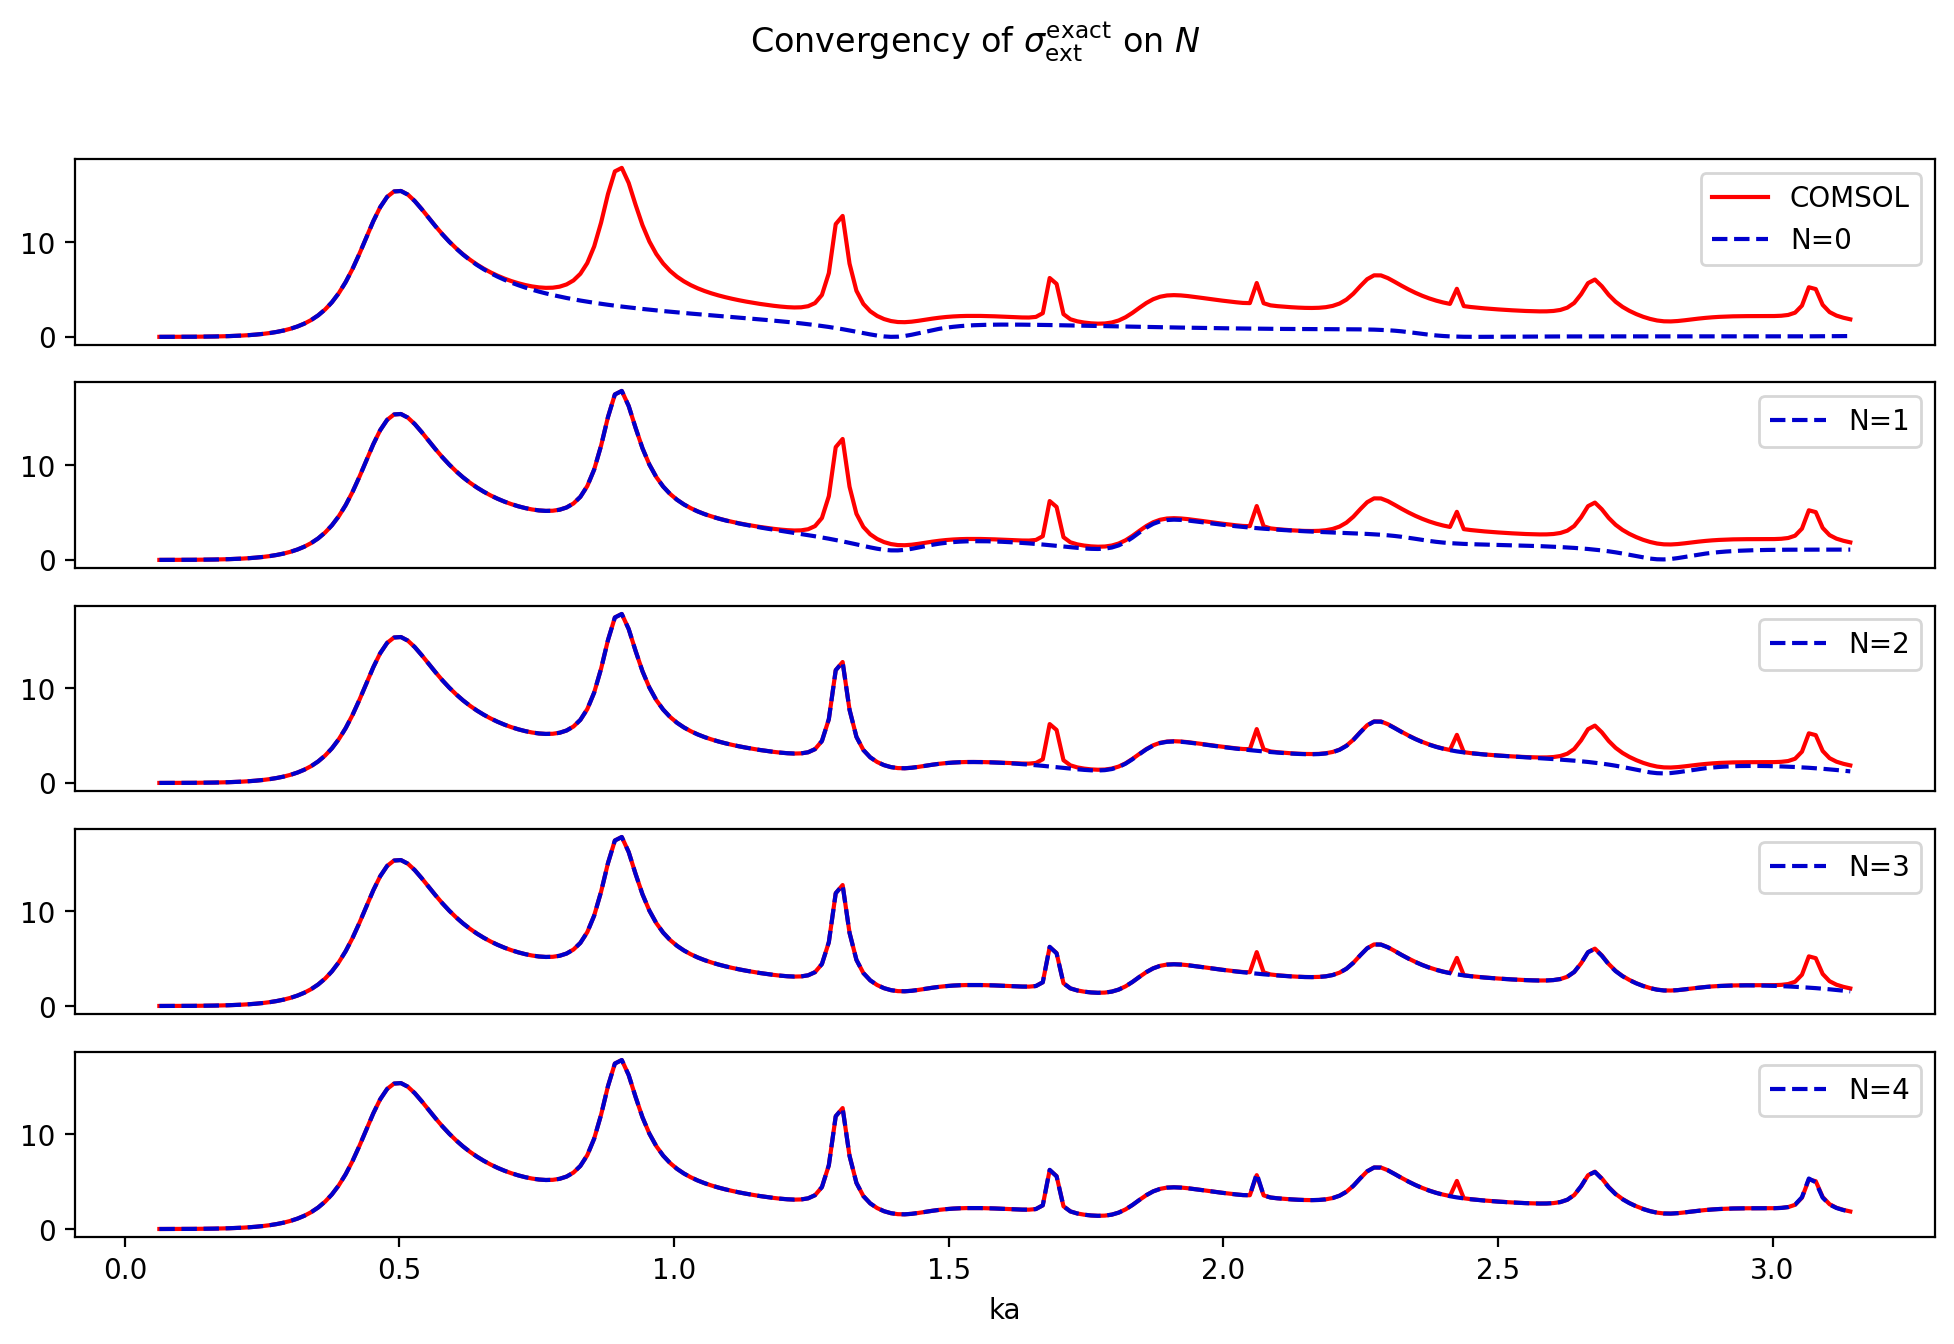

In [8]:
k_list = (
    2 * np.pi * df_comsol["freq"].to_numpy() / c_host
)  # Convert frequencies to wavenumbers
sigma_geom = np.pi * a**2  # Geometric cross section of the sphere

plt.figure(figsize=(12, 7), dpi=200)

N_list = [0, 1, 2, 3, 4]  # Maximum order of expansion N
for i, N in enumerate(N_list):

    plt.subplot(len(N_list), 1, i + 1)

    # Compute Mie coefficients and extinction cross section
    a_n = a_n_sphere(N, k_list, a, c_host, rho_host, c_sphere, rho_sphere)
    sigma_ext_exact = (
        -4 * np.pi / k_list**2 * np.real((2 * np.arange(N + 1) + 1.0) @ a_n)
    )

    # Plot COMSOL results
    plt.plot(
        a * k_list,
        df_comsol["sigma_ext"] / sigma_geom,
        "-",
        color="red",
        label="COMSOL" if i == 0 else None,
    )
    # Plot  analytical results
    plt.plot(
        k_list * a,
        sigma_ext_exact / sigma_geom,
        label=f"N={N}",
        linestyle="--",
        color="mediumblue",
    )
    plt.legend()

    if i != len(N_list) - 1:
        plt.xticks([])

plt.xlabel("ka")
plt.suptitle("Convergency of $\\sigma_\\text{ext}^\\text{exact}$ on $N$")
plt.show()

Now we have verified all the functions required for the subsequent calculations.